imports part

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

Load News Dataset

In [2]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news_df.head()
analyzer = SentimentIntensityAnalyzer()

Select Important Columns part

In [3]:
news_df = news_df[[
    "headline",
    "date",
    "stock"
]]

news_df.head()

,headline,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,2020-05-26 04:30:07-04:00,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:06-04:00,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:59-04:00,A


Convert Date part

In [4]:
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

news_df["date"] = news_df["date"].dt.date

news_df.head()

,headline,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,A
2,71 Biggest Movers From Friday,2020-05-26,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,A


sentiment analysis

analyzer = SentimentIntensityAnalyzer()
news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

news_df.head()


sentiment catagories

In [5]:
def classify_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"
    news_df["sentiment_category"] = news_df[
        "sentiment_score"
    ].apply(classify_sentiment)


news_df.head()

,headline,date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,A
2,71 Biggest Movers From Friday,2020-05-26,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,A


In [6]:
news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)
goog_news = news_df[
    news_df["stock"] == "GOOG"
]

goog_news.head()

,headline,date,stock,sentiment_score
565380,"Facebook, Snap Analyst Projects Q2 Revenue Ups...",2020-06-10,GOOG,0.0000
565381,How Cannabis Company Cannaphyll Is Marketing O...,2020-06-10,GOOG,0.1779
565382,"Twitter, Square Will Mark Juneteenth As Holida...",2020-06-10,GOOG,0.7096
565383,Price Over Earnings Overview: Alphabet,2020-06-09,GOOG,0.0000
565384,Google Maps To Offer Relevant Local COVID-19 I...,2020-06-09,GOOG,0.0000


Aggregate Daily Sentiment

In [7]:

daily_sentiment = goog_news.groupby("date")[
    "sentiment_score"
].mean().reset_index()

daily_sentiment.head()

,date,sentiment_score
0,2018-11-13,0.00000
1,2018-11-14,0.40370
2,2018-11-15,0.21800
3,2018-11-16,-0.10175
4,2018-11-17,0.20230


Load GOOG Stock Data

In [8]:
stock_df = pd.read_csv("../data/raw/GOOG.csv")

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


convert stock dates

In [9]:
stock_df["Date"] = pd.to_datetime(
    stock_df["Date"]
)

stock_df["Date"] = stock_df["Date"].dt.date

stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


calculate daily returns and match dates

In [10]:
stock_df["Daily_Return"] = stock_df[
    "Close"
].pct_change() * 100

stock_df.head()
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on="date",
    right_on="Date",
    how="inner"
)

merged_df.head()

,date,sentiment_score,Date,Close,High,Low,Open,Volume,Daily_Return
0,2018-11-13,0.00000,2018-11-13,51.450417,52.471179,51.207079,51.809956,30274000,-0.248399
1,2018-11-14,0.40370,2018-11-14,51.828323,52.369818,51.199626,52.143170,31318000,0.734507
2,2018-11-15,0.21800,2018-11-15,52.873669,53.228241,51.238360,51.880465,36722000,2.016938
3,2018-11-16,-0.10175,2018-11-16,52.713764,52.987389,52.092516,52.610471,33162000,-0.302427
4,2018-11-19,-0.08030,2018-11-19,50.653362,52.679001,50.467633,52.500721,37172000,-3.908660


correlation and scatter plots

Correlation: 0.18952771895249756
P-value: 0.0003493345774914755


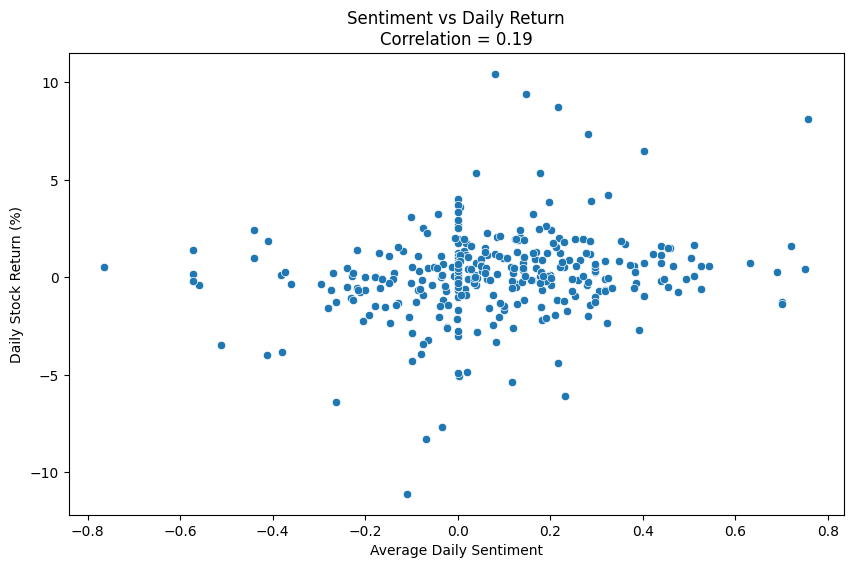

In [11]:
correlation, p_value = pearsonr(
    merged_df["sentiment_score"],
    merged_df["Daily_Return"]
)

print("Correlation:", correlation)
print("P-value:", p_value)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="sentiment_score",
    y="Daily_Return"
)

plt.title(
    f"Sentiment vs Daily Return\nCorrelation = {correlation:.2f}"
)

plt.xlabel("Average Daily Sentiment")

plt.ylabel("Daily Stock Return (%)")

plt.show()

Average Return by Sentiment Category

In [12]:
def classify_sentiment(score):

    if score > 0.05:
        return "Positive"

    elif score < -0.05:
        return "Negative"

    else:
        return "Neutral"
    
goog_news["sentiment_category"] = goog_news[
        "sentiment_score"
    ].apply(classify_sentiment)

category_df = goog_news.groupby(
    ["date", "sentiment_category"]
)["sentiment_score"].mean().reset_index()

category_df = pd.merge(
    category_df,
    stock_df,
    left_on="date",
    right_on="Date",
    how="inner"
)

avg_returns = category_df.groupby(
    "sentiment_category"
)["Daily_Return"].mean()

avg_returns

sentiment_category
Negative   -0.206850
Neutral     0.131013
Positive    0.310656
Name: Daily_Return, dtype: float64

barchart

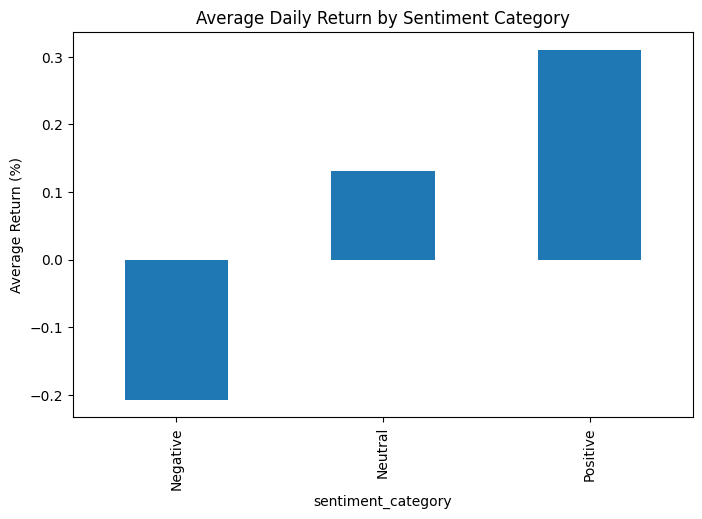

In [13]:
avg_returns.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Average Daily Return by Sentiment Category"
)

plt.ylabel("Average Return (%)")

plt.show()

Interpretation of Results

The correlation analysis examined the relationship between financial news sentiment and daily stock returns for GOOG stock.

The Pearson correlation coefficient indicates the strength and direction of the relationship between sentiment scores and stock price movement. A positive correlation suggests that positive news sentiment is associated with higher stock returns, while a negative correlation suggests the opposite.

The scatter plot shows that sentiment and stock returns exhibit a weak relationship, which is expected because stock prices are influenced by many additional factors including macroeconomic events, earnings reports, market volatility, and investor behavior.

The analysis also revealed differences in average stock returns across positive, neutral, and negative sentiment categories.

Although sentiment analysis provides useful market insights, limitations include:
- delayed market reactions
- multiple news events occurring simultaneously
- external economic factors
- simplified sentiment scoring methods